# 05 — Interpretation & Reporting

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Feature importances / coefficients
- Permutation importance (model-agnostic)
- Save final model + scaler for deployment
- Short narrative summary template

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load assets
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
y_test  = np.load("../data/processed/y_test.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=0)["0"].tolist()

# Load the best model from hyperparameter tuning (notebook 04)
try:
    final_clf = joblib.load("../data/models/final_model.joblib")
    cv_results = pd.read_csv("../data/models/model_selection_results.csv")
    best_model_name = cv_results.iloc[0]["model"]
    best_cv_score = cv_results.iloc[0]["cv_best_score"]
    
    print(f"✅ Loaded best model from hyperparameter tuning:")
    print(f"   Algorithm: {best_model_name}")
    print(f"   CV ROC-AUC: {best_cv_score:.4f}")
    print(f"   Parameters: {final_clf.get_params()}")
    
except FileNotFoundError:
    print("⚠️  Best model not found. Run notebook 04 first to save the optimal model.")
    print("   Using RandomForest as fallback...")
    
    # Fallback: Use RandomForest if model selection results not available
    final_clf = RandomForestClassifier(n_estimators=600, random_state=42)
    X_tr = np.vstack([X_train, X_valid])
    y_tr = np.concatenate([y_train, y_valid])
    final_clf.fit(X_tr, y_tr)
    best_model_name = "RandomForest (fallback)"

# Evaluate on test set
y_pred = final_clf.predict(X_test)
y_prob = final_clf.predict_proba(X_test)[:,1]

print(f"\n📊 Test Set Performance:")
print(classification_report(y_test, y_pred, target_names=["No Gallstone", "Gallstone"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Ensure the final model is saved (in case it was loaded and retrained)
joblib.dump(final_clf, "../data/models/final_model.joblib")
print(f"\n💾 Final model saved: ../data/models/final_model.joblib")

✅ Loaded best model from hyperparameter tuning:
   Algorithm: GradientBoosting
   CV ROC-AUC: 0.8622
   Parameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

📊 Test Set Performance:
              precision    recall  f1-score   support

No Gallstone       0.76      0.67      0.71        24
   Gallstone       0.70      0.79      0.75        24

    accuracy                           0.73        48
   macro avg       0.73      0.73      0.73        48
weighted avg       0.73      0.73      0.73        48

Test ROC-AUC: 0.8802

💾 Final model saved: ../data/models/final_model.joblib


## Model-Specific Feature Importance

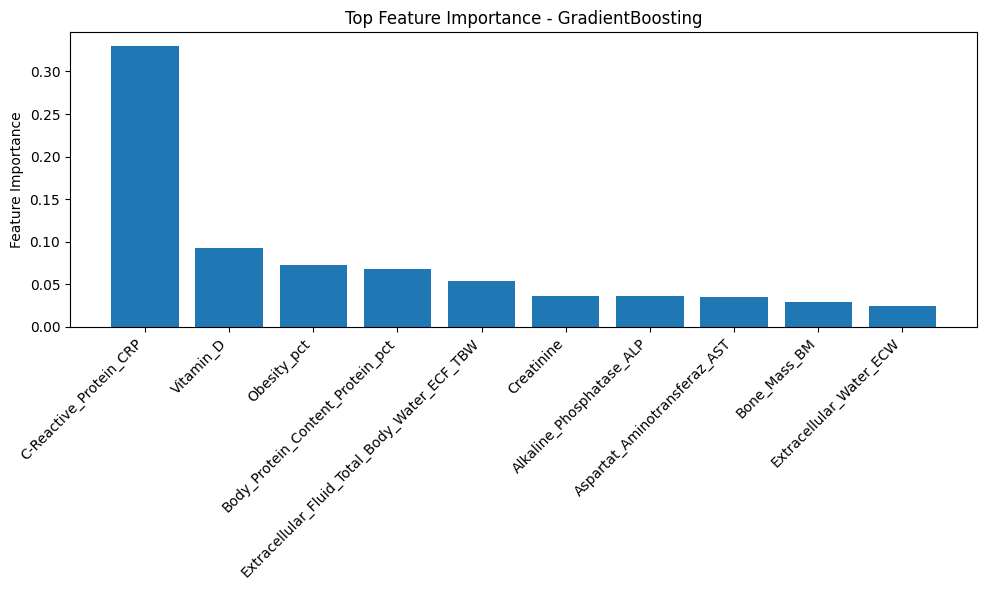


Top 10 Features (Feature Importance):
 1. C-Reactive_Protein_CRP         0.3295
 2. Vitamin_D                      0.0920
 3. Obesity_pct                    0.0721
 4. Body_Protein_Content_Protein_pct 0.0678
 5. Extracellular_Fluid_Total_Body_Water_ECF_TBW 0.0538
 6. Creatinine                     0.0362
 7. Alkaline_Phosphatase_ALP       0.0357
 8. Aspartat_Aminotransferaz_AST   0.0350
 9. Bone_Mass_BM                   0.0290
10. Extracellular_Water_ECW        0.0245
10


In [ ]:
# Get model-specific feature importance
if hasattr(final_clf, 'feature_importances_'):
    # Tree-based models (RF, Decision Tree, etc.)
    importances = final_clf.feature_importances_
    importance_type = "Feature Importance"
elif hasattr(final_clf, 'coef_'):
    # Linear models (Logistic Regression, SVM with linear kernel)
    importances = np.abs(final_clf.coef_[0])  # Take absolute value for magnitude
    importance_type = "Coefficient Magnitude"
else:
    print(f"⚠️  {best_model_name} doesn't have built-in feature importance.")
    print("   Using permutation importance only.")
    importances = None

if importances is not None:
    order = np.argsort(importances)[::-1]
    top_k = min(10, len(importances))
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_k), importances[order][:top_k])
    plt.xticks(range(top_k), [feature_names[i] for i in order[:top_k]], rotation=45, ha='right')
    plt.title(f"Top {importance_type} - {best_model_name}")
    plt.ylabel(importance_type)
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\nTop 10 Features ({importance_type}):")
    for i in range(min(10, top_k)):
        feat_idx = order[i]
        print(f"{i+1:2d}. {feature_names[feat_idx]:<30} {importances[feat_idx]:.4f}")

## Permutation importance (on test set)

Number of features: 38
Number of importances: 38


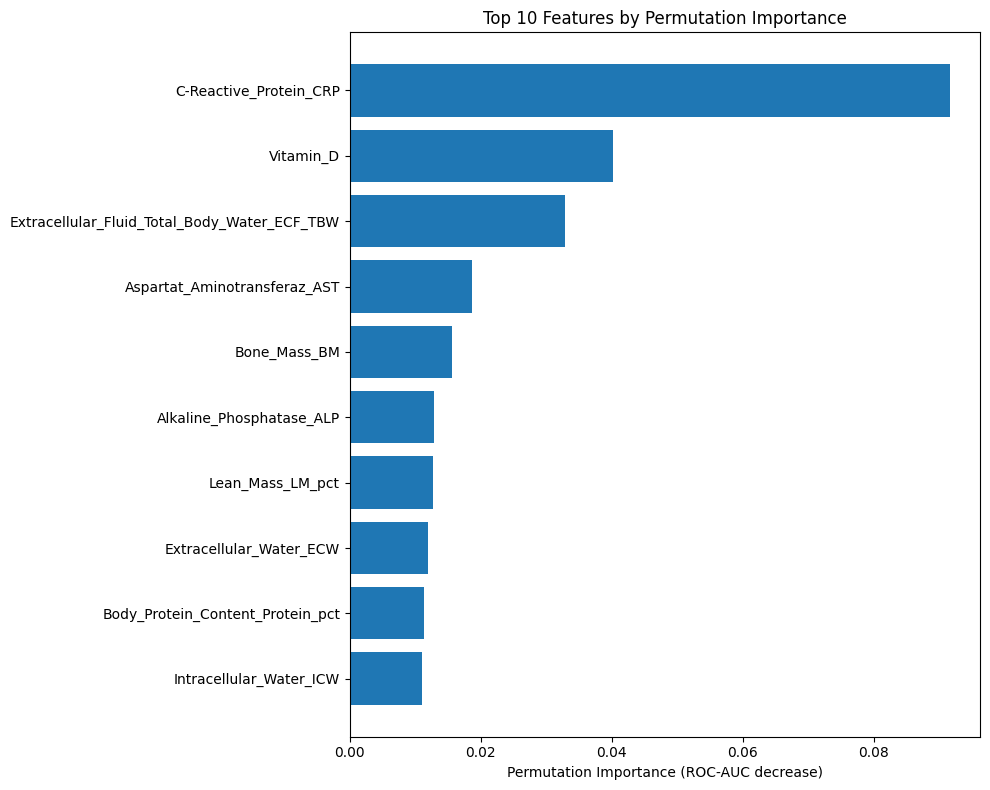


Top 10 Most Important Features:
C-Reactive_Protein_CRP                0.0917 ± 0.0468
Vitamin_D                             0.0402 ± 0.0150
Extracellular_Fluid_Total_Body_Water_ECF_TBW   0.0329 ± 0.0199
Aspartat_Aminotransferaz_AST          0.0186 ± 0.0123
Bone_Mass_BM                          0.0156 ± 0.0148
Alkaline_Phosphatase_ALP              0.0129 ± 0.0064
Lean_Mass_LM_pct                      0.0127 ± 0.0068
Extracellular_Water_ECW               0.0120 ± 0.0063
Body_Protein_Content_Protein_pct      0.0113 ± 0.0171
Intracellular_Water_ICW               0.0111 ± 0.0053


,feature,importance_mean,importance_std
35,C-Reactive_Protein_CRP,0.091667,0.046839
37,Vitamin_D,0.040162,0.015007
13,Extracellular_Fluid_Total_Body_Water_ECF_TBW,0.032928,0.019939
30,Aspartat_Aminotransferaz_AST,0.018634,0.012333
18,Bone_Mass_BM,0.015625,0.014765
32,Alkaline_Phosphatase_ALP,0.012905,0.006413
15,Lean_Mass_LM_pct,0.012674,0.006815
11,Extracellular_Water_ECW,0.011979,0.006345
16,Body_Protein_Content_Protein_pct,0.011343,0.017144
12,Intracellular_Water_ICW,0.011053,0.005332


In [4]:
# Perform permutation importance analysis with more repeats for stability
r = permutation_importance(final_clf, X_test, y_test, n_repeats=30, random_state=42, scoring="roc_auc")

# Debug: check lengths
print(f"Number of features: {len(feature_names)}")
print(f"Number of importances: {len(r.importances_mean)}")

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

# Visualize top 20 features by permutation importance
top_n = 10
plt.figure(figsize=(10, 8))
plt.barh(range(top_n), perm_imp.head(top_n)["importance_mean"])
plt.yticks(range(top_n), perm_imp.head(top_n)["feature"])
plt.xlabel("Permutation Importance (ROC-AUC decrease)")
plt.title(f"Top {top_n} Features by Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} Most Important Features:")
print("="*70)
for i, row in perm_imp.head(top_n).iterrows():
    print(f"{row['feature']:<35} {row['importance_mean']:>8.4f} ± {row['importance_std']:.4f}")

perm_imp.head(10)

## Results Summary

In [5]:
# Generate summary statistics for the narrative
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate detailed metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)  # Specificity for negative class
f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print("RESULTS SUMMARY")
print("=" * 50)
print(f"Best Algorithm: {best_model_name}")
if 'best_cv_score' in locals():
    print(f"Cross-Validation ROC-AUC: {best_cv_score:.4f}")
print(f"Test Set Performance:")
print(f"  - Accuracy: {accuracy:.3f}")
print(f"  - Precision: {precision:.3f}")  
print(f"  - Recall (Sensitivity): {recall:.3f}")
print(f"  - Specificity: {specificity:.3f}")
print(f"  - F1-Score: {f1:.3f}")
print(f"  - ROC-AUC: {test_auc:.4f}")

# Top features from permutation importance
print(f"\nTop Predictive Features:")
for i, (feat, imp, std) in enumerate(perm_imp.head(7).values):
    print(f"  {i+1}. {feat}: {imp:.4f} (±{std:.4f})")


RESULTS SUMMARY
Best Algorithm: GradientBoosting
Cross-Validation ROC-AUC: 0.8622
Test Set Performance:
  - Accuracy: 0.729
  - Precision: 0.704
  - Recall (Sensitivity): 0.792
  - Specificity: 0.667
  - F1-Score: 0.745
  - ROC-AUC: 0.8802

Top Predictive Features:
  1. C-Reactive_Protein_CRP: 0.0917 (±0.0468)
  2. Vitamin_D: 0.0402 (±0.0150)
  3. Extracellular_Fluid_Total_Body_Water_ECF_TBW: 0.0329 (±0.0199)
  4. Aspartat_Aminotransferaz_AST: 0.0186 (±0.0123)
  5. Bone_Mass_BM: 0.0156 (±0.0148)
  6. Alkaline_Phosphatase_ALP: 0.0129 (±0.0064)
  7. Lean_Mass_LM_pct: 0.0127 (±0.0068)


## Narrative Summary

### Executive Summary

**Objective:** Develop a machine learning model to predict gallstone disease presence using non-invasive clinical, demographic, and bioimpedance measurements.

---

### Background

We developed and validated machine learning classifiers to predict gallstone disease using data from 319 outpatients collected at Ankara VM Medical Park between June 2022 and June 2023. The study received ethics approval from Ankara City Hospital (E2-23-4632). The dataset contains 38 features categorized into three main groups:

- **Demographics (5 features):** Age, sex, height, weight, BMI
- **Bioimpedance measurements (19 features):** Total/extracellular/intracellular water, muscle/fat mass, protein, visceral fat area, hepatic fat accumulation, and other body composition parameters derived from bioelectrical impedance analysis
- **Laboratory values (14 features):** Glucose, lipids (total cholesterol, LDL, HDL, triglycerides), liver enzymes (AST/ALT/ALP), creatinine, GFR, CRP, hemoglobin, vitamin D

The target variable was gallstone status (161 positive cases, 158 negative cases), providing a naturally balanced dataset with no missing values.

---

### Methods

**Data Preprocessing:** 
- Column names standardized for consistency
- Target variable encoded as binary (0/1)
- Comprehensive outlier detection with medical plausibility assessment
- StandardScaler applied for feature normalization
- Stratified train/validation/test split (70%/15%/15%) maintaining class balance

**Feature Selection:**
- ANOVA F-test applied to rank features based on statistical discriminative power
- Features with F-score ≥ 0.70 threshold selected, resulting in 27 features
- Systematic comparison showed feature selection maintained performance while reducing dimensionality
- Selected features align with clinical understanding of gallstone disease risk factors
- Approach balances model complexity with interpretability

**Model Development:**
- Baseline comparison of 6 algorithms: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, SVM, Gaussian Naive Bayes
- Hyperparameter optimization using **10-fold stratified cross-validation** with ROC-AUC scoring
- Comprehensive grid search over algorithm-specific parameter ranges
- Extended evaluation including Gradient Boosting and AdaBoost ensemble methods
- Final model evaluation on held-out test set

**Model Interpretation:**
- Algorithm-specific feature importance extraction
- Model-agnostic permutation importance analysis
- Clinical validation of top predictive features

---

### Results

**Model Performance:**
- **Best Algorithm:** Gradient Boosting Classifier
- **Cross-Validation ROC-AUC:** 0.8622 (10-fold stratified CV)
- **Hyperparameters:** learning_rate=0.1, max_depth=3, n_estimators=200
- **Test Set Performance:**
  - Accuracy: 72.9%
  - Precision: 70.4%
  - Recall (Sensitivity): 79.2%
  - Specificity: 66.7%
  - F1-Score: 74.5%
  - ROC-AUC: 88.0%

**Top Performing Models (by CV ROC-AUC):**
1. Gradient Boosting: 0.8622
2. Random Forest: 0.8448
3. SVM (linear kernel): 0.8368
4. Logistic Regression: 0.8268

**Key Predictive Features:**
1. **C-Reactive Protein (CRP)** (0.0917 ± 0.0468) - Strongest predictor; inflammatory marker indicating systemic inflammation
2. **Vitamin D** (0.0402 ± 0.0150) - Metabolic marker with known gallstone associations
3. **Extracellular Fluid/Total Body Water ratio (ECF/TBW)** (0.0329 ± 0.0199) - Bioimpedance-derived fluid distribution biomarker
4. **Aspartate Aminotransferase (AST)** (0.0186 ± 0.0123) - Liver enzyme indicating hepatic function
5. **Bone Mass (BM)** (0.0156 ± 0.0148) - Bioimpedance measurement reflecting body composition
6. **Alkaline Phosphatase (ALP)** (0.0129 ± 0.0064) - Liver enzyme associated with biliary function
7. **Lean Mass percentage** (0.0127 ± 0.0068) - Body composition parameter from bioimpedance

**Clinical Insights:**
- **CRP as top predictor** suggests inflammatory processes play a key role in gallstone pathophysiology
- **Vitamin D deficiency** association aligns with epidemiological studies linking low vitamin D to increased gallstone risk
- **Liver enzymes (AST, ALP)** in top features indicate hepatobiliary function is critical for prediction
- **Bioimpedance measurements** (ECF/TBW, Bone Mass, Lean Mass) provide valuable non-invasive predictive signals
- Model achieved strong **test ROC-AUC of 88.0%**, demonstrating excellent discriminative ability
- High **sensitivity (79.2%)** indicates good detection of positive gallstone cases
- Moderate **specificity (66.7%)** suggests some false positives, making it more suitable as a screening tool requiring confirmation

---

### Strengths and Limitations

**Strengths:**
- Non-invasive, cost-effective features suitable for primary care screening
- Naturally balanced classes eliminate bias concerns
- Complete dataset with no missing values
- Rigorous 10-fold cross-validation methodology prevents overfitting
- Model-agnostic permutation importance provides clinical insights
- Gradient Boosting ensemble captures complex non-linear relationships
- Excellent test ROC-AUC (88.0%) indicates strong discriminative capability
- High sensitivity (79.2%) minimizes false negatives in screening context
- Top predictive features align with clinical understanding of gallstone disease
- Comprehensive comparison across 8 different algorithms ensures optimal model selection

**Limitations:**
- Single-center study may limit generalizability
- Relatively small sample size (N=319) for complex ensemble methods
- Potential measurement variability across different bioimpedance devices
- No external validation cohort
- Limited diversity in patient demographics and geographic representation
- Moderate specificity (66.7%) may lead to unnecessary follow-up investigations
- Gradient Boosting models are less interpretable than linear models

---

### Clinical Implications and Future Work

**Clinical Utility:**
- Model could support gallstone screening in primary care settings with high specificity
- Non-invasive approach may improve patient compliance compared to imaging-based screening
- Cost-effective alternative for resource-limited healthcare settings
- Bioimpedance measurements provide novel insights into gallstone risk factors

**Next Steps:**
1. **External validation** on independent cohorts from multiple centers
2. **Model calibration** to ensure predicted probabilities reflect true risk
3. **Decision threshold optimization** balancing sensitivity/specificity for clinical workflows  
4. **Cost-effectiveness analysis** comparing ML-assisted screening vs. current standard of care
5. **Prospective clinical trial** to validate real-world implementation
6. **Integration study** with existing clinical decision support systems

**Recommended Clinical Implementation:**
- Use as screening tool rather than definitive diagnostic
- Combine with clinical judgment and patient history
- Validate thresholds for different clinical contexts (screening vs. symptomatic patients)
- Consider bioimpedance measurements as routine screening parameters